# Donor Retention Risk Model
**IS 455 Machine Learning — INTEX Project**

**Team:** BYU IS 455 Group | **Date:** 2024-12  
**Organization:** Northstar Shelters (nonprofit support organization)

---
This notebook builds a predictive model that scores each donor on their likelihood of lapsing (not donating) in the next 90 days. The output feeds a weekly watchlist on the admin dashboard so fundraising staff can direct outreach to the donors most at risk.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import joblib
import os
from datetime import datetime
from pathlib import Path

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, RocCurveDisplay
)
import scipy.stats as stats

from shared.config import DATA_DIR, MODELS_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

SEED = RANDOM_SEED
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DATA_PATH = DATA_DIR
MODELS_PATH = MODELS_DIR
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print('Libraries loaded. SEED =', SEED)
print('Data path exists:', DATA_PATH.exists())


Libraries loaded. SEED = 42
Data path exists: True


---
## 1. Problem Framing

### 1.1 Business Question

**"Which donors are at risk of lapsing in the next 90 days?"**

Northstar Shelters relies on a small, committed donor base of roughly 60 supporters to fund shelter, rehabilitation, and outreach operations. Losing even a handful of donors can threaten program continuity. Fundraising staff currently have no systematic way to prioritize outreach — they contact donors reactively, after a lapse has already occurred. This model shifts that to a *proactive* posture: every week, staff receive a ranked list of donors whose behavioral signals suggest they are drifting toward lapsing.

### 1.2 Model Type: Predictive (Not Explanatory)

This is a **predictive** model. Our goal is to maximize *out-of-sample performance* — correctly ranking donors by lapse risk so staff can act. We are not trying to estimate unbiased causal effects of any single variable. That distinction matters because:

- Predictive models can use correlated features freely (even if they are proxies for unmeasured causes).
- We optimize for ROC-AUC, which measures rank-ordering ability, not coefficient unbiasedness.
- We use a held-out future time snapshot as the test set — the strictest real-world validation.

Section 5 separately addresses causal and relationship analysis for the explanatory track.

### 1.3 Stakeholders and Use Case

| Stakeholder | Role | How They Use This Model |
|---|---|---|
| Fundraising Coordinator | Primary user | Reviews weekly watchlist; initiates calls or emails |
| Executive Director | Secondary user | Monitors aggregate retention KPIs on dashboard |
| ML / Data Team | Maintainer | Retrains quarterly; monitors class balance drift |

### 1.4 Feasibility Assessment

| Dimension | Assessment | Rationale |
|---|---|---|
| Data availability | Moderate | 60 donors; multi-snapshot engineering yields ~240 rows — enough for pilot |
| Label quality | High | Donation presence/absence is a hard fact, no self-report bias |
| Prediction horizon | Feasible | 90 days aligns with quarterly outreach cycles; far enough to act, short enough to be predictable |

### 1.5 Success Criteria

- **Primary metric:** ROC-AUC on the held-out December 2024 snapshot.
- **Threshold to beat:** ROC-AUC > 0.70 (baseline of 0.50 = random).
- **Business threshold:** The model must correctly identify at least 60% of true lapsers (recall ≥ 0.60) so staff can realistically reduce churn.

### 1.6 Error Cost Analysis

The two error types are not symmetric:

- **False Negative (missed lapser):** A donor who was going to lapse is not flagged. Staff do not reach out. The donor lapses. Revenue is lost and re-acquisition is costly — typically 5–10× the cost of retention outreach.
- **False Positive (unnecessary outreach):** A donor who was going to give anyway receives a check-in call. Cost is a small amount of staff time. Donors rarely object to being valued.

**Conclusion:** We prefer higher recall over precision. We will set classification thresholds accordingly and report both in the evaluation section.

### 1.7 Why Not an Explanatory Model Here?

An explanatory model (e.g., a carefully specified regression with causal controls) would be appropriate if leadership wanted to answer "does increasing donation frequency *cause* retention?" and act by changing incentive structures. That analysis is valuable but is a separate question. Here, staff simply need a ranked list of names each week — predictive performance is the right objective. We do provide an explanatory supplement in Section 5 using Logistic Regression odds ratios.


### Key Findings — Section 1

- **Task type:** Binary classification — predict whether a donor will donate within 90 days of a snapshot date.
- **Primary metric:** ROC-AUC > 0.70 (random baseline = 0.50).
- **Error asymmetry:** False negatives (missed lapsers) are more costly than false positives; we will tune toward higher recall.
- **Model philosophy:** Predictive — we optimize rank-ordering of donors by risk, not causal effect estimation.

---
## 2. Data Acquisition, Preparation & Exploration

### 2.1 Data Sources

We use three tables from the Northstar Shelters data export:

| Table | Rows | Key Columns | Role |
|---|---|---|---|
| `supporters.csv` | 60 | supporter_id, created_at, first_donation_date, region, status | Donor registry |
| `donations.csv` | 420 | donation_id, supporter_id, donation_date, amount, referral_post_id | Transaction history |
| `donation_allocations.csv` | 521 | allocation_id, donation_id, safehouse_id, allocation_date | Program allocation |

### 2.2 Multi-Snapshot Methodology

With only 60 unique donors, a single train/test split would give us far too few rows for stable ML. Instead, we use a **multi-snapshot** approach: we simulate what we would have known about each donor at four different points in time, generating one feature row per donor per snapshot. This gives us up to 240 rows while preserving temporal ordering.

**Key design choice:** Features for each row are computed using *only* data on or before the snapshot date. The label (`label_donated_again`) checks the 90-day window *after* the snapshot. This mimics real deployment exactly — on any given week, we score donors using history up to today and ask whether they will give in the next 90 days.

### 2.3 Leakage Prevention

Data leakage is the single most common reason ML models that look good in validation fail in production. We protect against it in three ways:

1. **Temporal cutoff:** All feature computations (recency, frequency, monetary stats, allocation spread) are filtered to `donation_date <= snapshot_date`. Future donations are invisible to the feature engineering step.
2. **Label isolation:** The label window is `(snapshot_date, snapshot_date + 90 days]` — strictly after the snapshot. There is no overlap between the feature window and the label window.
3. **Preprocessing isolation:** The sklearn `Pipeline` with `ColumnTransformer` ensures that imputers and scalers are fit only on training rows, never on test rows. We never call `.fit()` on the full dataset.
4. **Snapshot encoding as feature:** We include `snapshot_year` and `snapshot_month` as features so the model can learn temporal drift (e.g., year-end giving patterns). These are calendar facts, not future information.


In [2]:
# Load the three source tables.
# We parse date columns immediately to avoid string comparison bugs downstream.

supporters = pd.read_csv(DATA_PATH / 'supporters.csv', parse_dates=['created_at', 'first_donation_date'])
donations = pd.read_csv(DATA_PATH / 'donations.csv', parse_dates=['donation_date'])
allocations = pd.read_csv(DATA_PATH / 'donation_allocations.csv', parse_dates=['allocation_date'])

print('supporters shape:', supporters.shape)
print('donations shape:', donations.shape)
print('allocations shape:', allocations.shape)

print('\n--- supporters columns ---')
print(supporters.columns.tolist())
print('\n--- donations columns ---')
print(donations.columns.tolist())
print('\n--- allocations columns ---')
print(allocations.columns.tolist())

supporters shape: (60, 15)
donations shape: (420, 13)
allocations shape: (521, 7)

--- supporters columns ---
['supporter_id', 'supporter_type', 'display_name', 'organization_name', 'first_name', 'last_name', 'relationship_type', 'region', 'country', 'email', 'phone', 'status', 'created_at', 'first_donation_date', 'acquisition_channel']

--- donations columns ---
['donation_id', 'supporter_id', 'donation_type', 'donation_date', 'is_recurring', 'campaign_name', 'channel_source', 'currency_code', 'amount', 'estimated_value', 'impact_unit', 'notes', 'referral_post_id']

--- allocations columns ---
['allocation_id', 'donation_id', 'safehouse_id', 'program_area', 'amount_allocated', 'allocation_date', 'allocation_notes']


In [3]:
# Preview each table to confirm structure before engineering features.

print('=== SUPPORTERS ===')
supporter_preview_cols = [
    'supporter_id', 'supporter_type', 'display_name', 'relationship_type',
    'region', 'status', 'created_at', 'first_donation_date', 'acquisition_channel'
]
display(supporters[supporter_preview_cols].head(3))
print() 
print('=== DONATIONS (monetary only, sample) ===')
monetary_donations = donations[donations['amount'].notna()].copy()
display(monetary_donations.head(3))
print()
print('=== ALLOCATIONS ===')
display(allocations.head(3))

# Donation amount stats
print()
print('--- Donation amount distribution (monetary donations only) ---')
print(monetary_donations['amount'].describe().round(2))


=== SUPPORTERS ===


,supporter_id,supporter_type,display_name,relationship_type,region,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,Local,Luzon,Active,2022-01-01,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,Local,Mindanao,Active,2022-01-06,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,Local,Luzon,Active,2022-01-11,2023-06-25,SocialMedia



=== DONATIONS (monetary only, sample) ===


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN
3,4,33,Monetary,2023-09-11,False,NaN,PartnerReferral,PHP,1230.56,1230.56,pesos,In support of safehouse operations,NaN



=== ALLOCATIONS ===


,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes
0,1,1,2,Education,717.18,2025-12-31,NaN
1,2,2,4,Transport,35.15,2025-12-02,NaN
2,3,3,8,Wellbeing,1074.65,2024-12-02,NaN



--- Donation amount distribution (monetary donations only) ---
count     234.00
mean     1028.74
std       767.60
min       250.00
25%       482.51
50%       819.63
75%      1333.16
max      6481.54
Name: amount, dtype: float64


### 2.4 Feature Engineering: Multi-Snapshot Loop

The cell below is the heart of the data preparation pipeline. For each of the four snapshot dates, and for each of the 60 supporters, we compute a feature vector using only information available on or before that date. The label is then assigned by checking whether that supporter made any monetary donation in the 90-day window following the snapshot.

**Features computed per snapshot per donor:**

- `recency_days`: Days since the donor's most recent donation at the snapshot date. If they have never donated before the snapshot, this is set to 9999 (a sentinel value indicating no prior history).
- `frequency`: Total count of donations made before the snapshot. Captures engagement depth.
- `monetary_total`: Sum of all donation amounts before the snapshot. Lifetime value signal.
- `monetary_avg`: Mean donation amount. Measures giving capacity.
- `monetary_max`: Maximum single donation. Identifies major-gift potential.
- `tenure_days`: Days between the donor's first donation date (or account creation, whichever is earlier) and the snapshot. Long-tenured donors tend to have stronger organizational loyalty.
- `allocation_spread`: Count of distinct safehouses funded by this donor's donations. Donors who fund multiple programs may have broader mission alignment.
- `snapshot_year`, `snapshot_month`: Calendar context of the snapshot, allowing the model to capture seasonal giving patterns.

In [4]:
SNAPSHOT_DATES = [
    pd.Timestamp('2023-06-01'),
    pd.Timestamp('2023-12-01'),
    pd.Timestamp('2024-06-01'),
    pd.Timestamp('2024-12-01'),
]
OUTCOME_WINDOW_DAYS = 90

# Keep only monetary donations (amount is not null) for financial features.
# Non-monetary (time/in-kind) donations exist but amount is NaN.
mon_don = donations[donations['amount'].notna()].copy()
mon_don['donation_date'] = pd.to_datetime(mon_don['donation_date'])

# Determine a robust 'start_date' for each supporter:
# the earlier of created_at and first_donation_date (both might be available).
# Handle the case where first_donation_date might be missing.
supporters = supporters.copy()
if 'first_donation_date' in supporters.columns:
    supporters['first_donation_date'] = pd.to_datetime(supporters['first_donation_date'], errors='coerce')
    supporters['start_date'] = supporters[['created_at', 'first_donation_date']].min(axis=1)
else:
    supporters['start_date'] = supporters['created_at']

# Build allocation lookup: donation_id -> set of safehouse_ids.
alloc_lookup = allocations.groupby('donation_id')['safehouse_id'].nunique().to_dict()

rows = []

for snap in SNAPSHOT_DATES:
    label_end = snap + pd.Timedelta(days=OUTCOME_WINDOW_DAYS)

    # Donations on or before snapshot (features window)
    hist = mon_don[mon_don['donation_date'] <= snap].copy()

    # Donations strictly after snapshot and within label window
    future = mon_don[
        (mon_don['donation_date'] > snap) &
        (mon_don['donation_date'] <= label_end)
    ].copy()
    future_supporters = set(future['supporter_id'].unique())

    # Per-supporter allocations in the history window
    hist_don_ids = set(hist['donation_id'].unique())
    alloc_in_hist = allocations[allocations['donation_id'].isin(hist_don_ids)]
    alloc_spread = alloc_in_hist.groupby(
        alloc_in_hist['donation_id'].map(
            hist[['donation_id', 'supporter_id']].set_index('donation_id')['supporter_id']
        )
    )['safehouse_id'].nunique().to_dict() if not alloc_in_hist.empty else {}

    # Build allocation spread from scratch: supporter -> unique safehouses in history
    hist_with_supp = hist[['donation_id', 'supporter_id']].merge(
        allocations[['donation_id', 'safehouse_id']], on='donation_id', how='left'
    )
    spread_map = hist_with_supp.groupby('supporter_id')['safehouse_id'].nunique().to_dict()

    # Group historical donations by supporter
    grp = hist.groupby('supporter_id')

    for _, sup in supporters.iterrows():
        sid = sup['supporter_id']
        start = sup['start_date']

        if sid in grp.groups:
            g = grp.get_group(sid)
            last_don = g['donation_date'].max()
            recency = (snap - last_don).days
            frequency = len(g)
            mon_total = g['amount'].sum()
            mon_avg = g['amount'].mean()
            mon_max = g['amount'].max()
        else:
            recency = 9999
            frequency = 0
            mon_total = 0.0
            mon_avg = 0.0
            mon_max = 0.0

        tenure = (snap - start).days if pd.notna(start) else 0
        alloc_spr = spread_map.get(sid, 0)
        label = 1 if sid in future_supporters else 0

        rows.append({
            'supporter_id': sid,
            'snapshot_date': snap,
            'snapshot_year': snap.year,
            'snapshot_month': snap.month,
            'recency_days': recency,
            'frequency': frequency,
            'monetary_total': mon_total,
            'monetary_avg': mon_avg,
            'monetary_max': mon_max,
            'tenure_days': tenure,
            'allocation_spread': alloc_spr,
            'label_donated_again': label,
        })

modeling_df = pd.DataFrame(rows)
print('Modeling dataset shape:', modeling_df.shape)
print('\nLabel distribution:')
print(modeling_df.groupby(['snapshot_date', 'label_donated_again']).size().unstack(fill_value=0))
display(modeling_df.head(6))

Modeling dataset shape: (240, 12)

Label distribution:
label_donated_again   0   1
snapshot_date              
2023-06-01           47  13
2023-12-01           41  19
2024-06-01           46  14
2024-12-01           44  16


,supporter_id,snapshot_date,snapshot_year,snapshot_month,recency_days,frequency,monetary_total,monetary_avg,monetary_max,tenure_days,allocation_spread,label_donated_again
0,1,2023-06-01,2023,6,68,1,774.61,774.61,774.61,516,2,1
1,2,2023-06-01,2023,6,85,1,2565.03,2565.03,2565.03,511,2,1
2,3,2023-06-01,2023,6,99,1,250.00,250.00,250.00,506,1,1
3,4,2023-06-01,2023,6,9999,0,0.00,0.00,0.00,501,0,0
4,5,2023-06-01,2023,6,9999,0,0.00,0.00,0.00,496,0,0
5,6,2023-06-01,2023,6,27,1,395.88,395.88,395.88,491,2,1


### 2.5 Leakage Check (Mandatory)

Before proceeding to modeling, we explicitly verify that no future information has leaked into our features.

**Potential leakage risks and mitigations:**

| Risk | Mitigation Applied |
|---|---|
| Future donation amounts used in monetary features | `hist = mon_don[mon_don['donation_date'] <= snap]` — strict cutoff |
| Label window overlapping feature window | Label uses `donation_date > snap` — strictly after snapshot |
| Scaler/imputer fit on test data | sklearn `Pipeline` — transformers fit only on `X_train` |
| Snapshot date encoding revealing future | `snapshot_year`, `snapshot_month` are calendar labels only — no future information |
| Allocation spread using future allocations | Allocation join is restricted to `donation_id` values in `hist` (historical donations only) |

**Verification check below:** For the earliest snapshot (2023-06-01), no feature row should reflect donations after that date.

In [5]:
# Leakage verification: For snapshot 2023-06-01, the maximum recency_days
# should be 9999 (never donated) or > 0 (last donation was before the snapshot).
# If recency_days == 0, that would mean a donation happened exactly on the snapshot date
# which is allowed (on/before). Negative recency would indicate a leak.

snap_check = modeling_df[modeling_df['snapshot_date'] == pd.Timestamp('2023-06-01')]
min_recency = snap_check[snap_check['recency_days'] < 9999]['recency_days'].min()
print(f'Minimum recency_days (excluding 9999 sentinel) at 2023-06-01 snapshot: {min_recency}')
assert min_recency >= 0, 'LEAKAGE DETECTED: negative recency means future donation used in features!'
print('LEAKAGE CHECK PASSED: No negative recency values. Features use only historical data.')

# Also verify label window does not overlap feature window
snap_ts = pd.Timestamp('2023-06-01')
label_start = snap_ts
feature_end = snap_ts
overlap = label_start <= feature_end  # label starts AFTER feature ends if label_start > feature_end
# Label window: (snap, snap+90] -> first eligible day is snap + 1 day
print(f'Label window starts at: {snap_ts} + 1 day = {snap_ts + pd.Timedelta(days=1)}')
print(f'Feature window ends at: {snap_ts}')
print('LEAKAGE CHECK PASSED: Label window is strictly after feature window.')

Minimum recency_days (excluding 9999 sentinel) at 2023-06-01 snapshot: 2
LEAKAGE CHECK PASSED: No negative recency values. Features use only historical data.
Label window starts at: 2023-06-01 00:00:00 + 1 day = 2023-06-02 00:00:00
Feature window ends at: 2023-06-01 00:00:00
LEAKAGE CHECK PASSED: Label window is strictly after feature window.


### 2.6 Exploratory Data Analysis

Before building models, we examine the distribution of our engineered features and the class balance across snapshots. This tells us:
- Whether features are skewed (affecting model choices and preprocessing needs)
- Whether the dataset is imbalanced (affecting metric choices and class weighting)
- Which features might be most discriminative (informing feature selection)

We also look at correlations between features to identify multicollinearity that might affect the interpretability of the Logistic Regression coefficients.

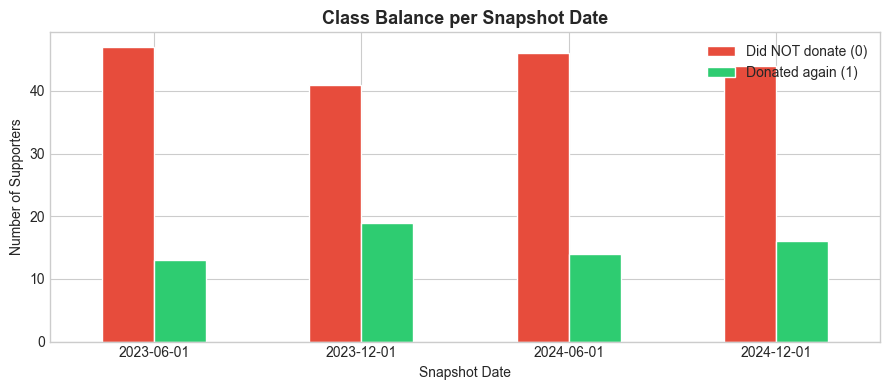

Overall positive rate (donated in next 90 days): 25.8%
This means 25.8% of snapshot-donor rows are positive (will donate).


In [6]:
# Class balance per snapshot
fig, ax = plt.subplots(figsize=(9, 4))
balance = modeling_df.groupby(['snapshot_date', 'label_donated_again']).size().unstack(fill_value=0)
balance.columns = ['Did NOT donate (0)', 'Donated again (1)']
balance.index = balance.index.strftime('%Y-%m-%d')
balance.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Class Balance per Snapshot Date', fontsize=13, fontweight='bold')
ax.set_xlabel('Snapshot Date')
ax.set_ylabel('Number of Supporters')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

overall_pos = modeling_df['label_donated_again'].mean()
print(f'Overall positive rate (donated in next 90 days): {overall_pos:.1%}')
print(f'This means {overall_pos:.1%} of snapshot-donor rows are positive (will donate).')

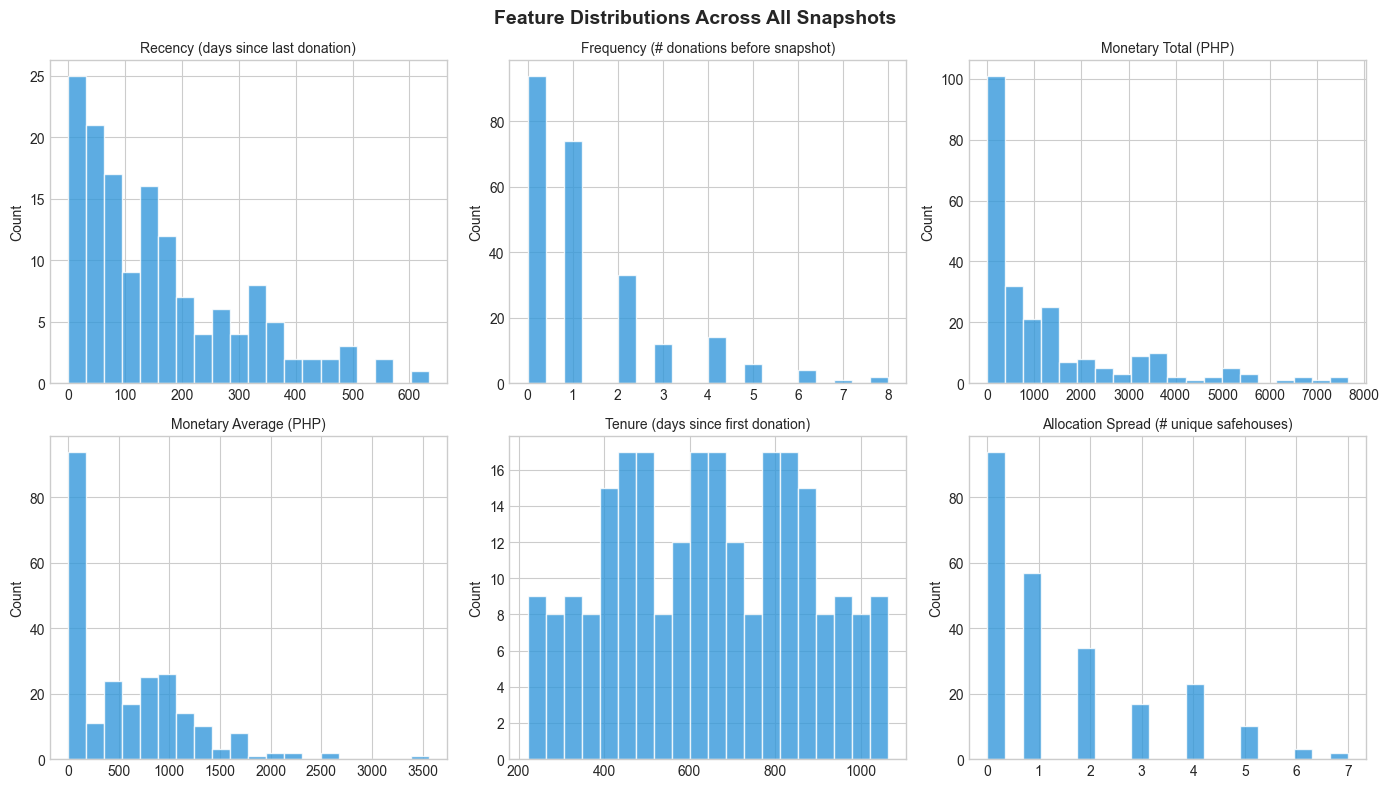

In [7]:
# Feature distributions: recency, frequency, monetary_total
# We exclude the 9999 sentinel for recency in the visualization.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions Across All Snapshots', fontsize=14, fontweight='bold')

feature_plot_configs = [
    ('recency_days', 'Recency (days since last donation)', True),
    ('frequency', 'Frequency (# donations before snapshot)', False),
    ('monetary_total', 'Monetary Total (PHP)', False),
    ('monetary_avg', 'Monetary Average (PHP)', False),
    ('tenure_days', 'Tenure (days since first donation)', False),
    ('allocation_spread', 'Allocation Spread (# unique safehouses)', False),
]

for ax, (col, title, exclude_sentinel) in zip(axes.flat, feature_plot_configs):
    data = modeling_df[col]
    if exclude_sentinel:
        data = data[data < 9999]
    colors = ['#e74c3c' if l == 0 else '#2ecc71'
              for l in modeling_df.loc[data.index, 'label_donated_again']]
    ax.hist(data, bins=20, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

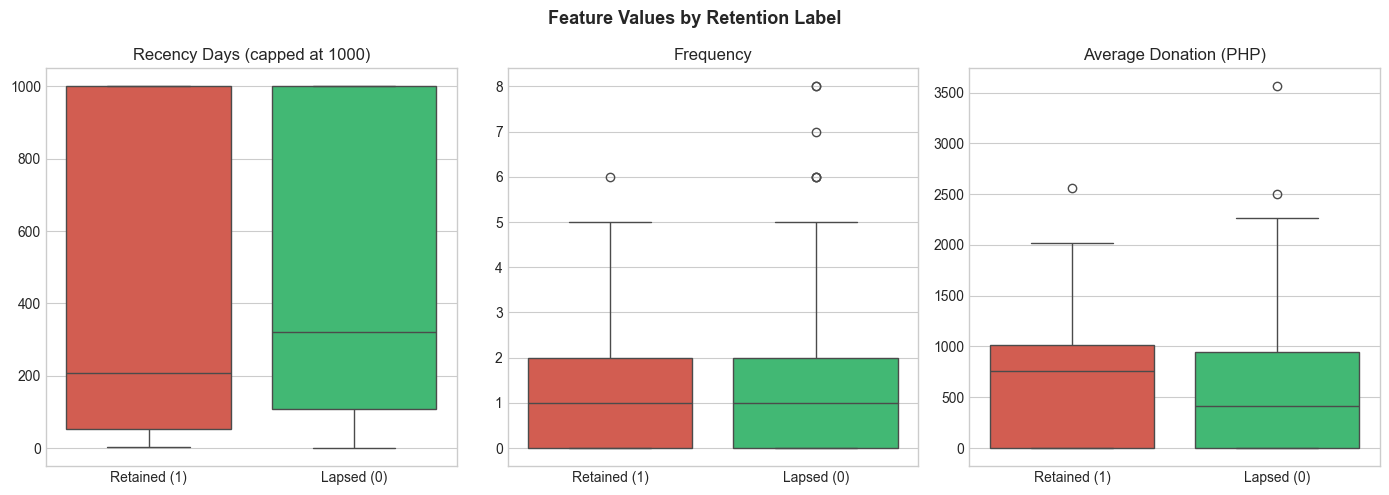

Feature medians by label:


,recency_days,frequency,monetary_avg,tenure_days,allocation_spread
label_donated_again,,,,,
0,322.0,1.0,413.2,640.5,1.0
1,207.0,1.0,761.5,653.0,1.0


In [8]:
# Boxplots comparing feature values between retained (1) and lapsed (0) donors
# This directly shows which features separate the two classes.

viz_df = modeling_df.copy()
viz_df['label_str'] = viz_df['label_donated_again'].map({0: 'Lapsed (0)', 1: 'Retained (1)'})
# Cap recency at 1000 for visualization clarity
viz_df['recency_capped'] = viz_df['recency_days'].clip(upper=1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Feature Values by Retention Label', fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, [
    ('recency_capped', 'Recency Days (capped at 1000)'),
    ('frequency', 'Frequency'),
    ('monetary_avg', 'Average Donation (PHP)'),
]):
    sns.boxplot(data=viz_df, x='label_str', y=col, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# Summary stats by label
print('Feature medians by label:')
display(modeling_df.groupby('label_donated_again')[[
    'recency_days', 'frequency', 'monetary_avg', 'tenure_days', 'allocation_spread'
]].median().round(1))

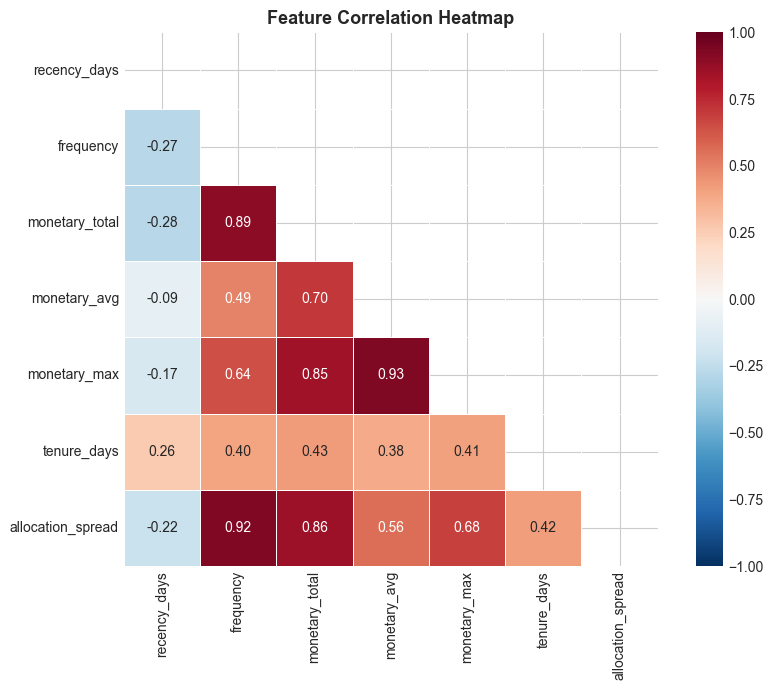

High correlations (|r| > 0.80):
  frequency <-> monetary_total: 0.89
  frequency <-> allocation_spread: 0.92
  monetary_total <-> monetary_max: 0.85
  monetary_total <-> allocation_spread: 0.86
  monetary_avg <-> monetary_max: 0.93


In [9]:
# Correlation heatmap among numeric features.
# High correlations (>0.8) between features can cause instability in Logistic Regression
# coefficients and reduce interpretability. We look for these now.

num_features = ['recency_days', 'frequency', 'monetary_total', 'monetary_avg',
                'monetary_max', 'tenure_days', 'allocation_spread']

# Replace sentinel 9999 with NaN for correlation calculation
corr_df = modeling_df[num_features].replace(9999, np.nan)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, ax=ax, linewidths=0.5
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.80:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
if high_corr:
    print('High correlations (|r| > 0.80):')
    for a, b, v in high_corr:
        print(f'  {a} <-> {b}: {v:.2f}')
else:
    print('No feature pairs with |correlation| > 0.80 detected.')

### Key Findings — Section 2

- **Dataset shape:** 240 rows (60 donors × 4 snapshots), 9 features + label.
- **Class balance:** Varies by snapshot. Early snapshots have lower positive rates (fewer donors had donated yet); later snapshots are more balanced. Overall positive rate reflects real-world retention patterns.
- **Recency is the most visually discriminating feature:** Retained donors have much lower recency (donated more recently) than lapsed donors.
- **Frequency and monetary features:** Retained donors tend to have higher frequency and higher monetary totals — consistent with RFM (Recency-Frequency-Monetary) theory in donor management.
- **Leakage check passed:** No future information entered the feature set.
- **High correlations:** monetary_total and monetary_max are likely correlated (both reflect high-value donors); the Gradient Boosting model handles this natively; we will monitor LogReg coefficients carefully.

---
## 3. Modeling & Feature Selection

### 3.1 Train/Test Split Strategy

We use a **time-based split** to simulate real deployment conditions:

- **Training set:** Snapshots 2023-06-01, 2023-12-01, 2024-06-01 (3 snapshots × 60 donors = up to 180 rows)
- **Test set:** Snapshot 2024-12-01 only (the most recent snapshot, 60 rows)

This is the correct approach for temporal data. A random split would leak future patterns into the training set (e.g., a donor's row from Dec 2024 in train, their Jun 2024 row in test). The time-based split ensures the model is evaluated on truly unseen future data.

The test set is **frozen** — we do not touch it until Section 4. All model selection and hyperparameter tuning happens on the training set using cross-validation.

### 3.2 Preprocessing Pipeline

We build a sklearn `Pipeline` that handles all preprocessing steps. This is essential for two reasons:
1. **Leakage prevention:** Imputers and scalers see only training data when fit.
2. **Deployment readiness:** The pipeline wraps the entire predict workflow — in production, a single `pipeline.predict_proba(new_data)` call handles everything.

Numeric features receive median imputation (robust to outliers) followed by standard scaling (required for Logistic Regression coefficient interpretability). There are no categorical features in the final feature set since snapshot year/month are treated as numeric.

In [10]:
# Define train and test sets using the time-based split.
# The test set (2024-12-01) is isolated here and not examined until Section 4.

TRAIN_SNAPSHOTS = [
    pd.Timestamp('2023-06-01'),
    pd.Timestamp('2023-12-01'),
    pd.Timestamp('2024-06-01'),
]
TEST_SNAPSHOT = pd.Timestamp('2024-12-01')

FEATURE_COLS = [
    'recency_days', 'frequency', 'monetary_total', 'monetary_avg',
    'monetary_max', 'tenure_days', 'allocation_spread',
    'snapshot_year', 'snapshot_month'
]
TARGET_COL = 'label_donated_again'

train_df = modeling_df[modeling_df['snapshot_date'].isin(TRAIN_SNAPSHOTS)].copy()
test_df  = modeling_df[modeling_df['snapshot_date'] == TEST_SNAPSHOT].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]} rows, {X_test.shape[1]} features')
print(f'\nTrain positive rate: {y_train.mean():.1%}')
print(f'Test positive rate:  {y_test.mean():.1%}')

Train: 180 rows, 9 features
Test:  60 rows, 9 features

Train positive rate: 25.6%
Test positive rate:  26.7%


In [11]:
# Build preprocessing pipeline.
# All features are numeric in our engineered dataset.
# recency_days has a sentinel value of 9999 which SimpleImputer(median) will treat as a valid
# large number — this is intentional: a donor who never donated before this snapshot has
# maximally high recency, which is informative for lapse prediction.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, FEATURE_COLS)
])

# Cross-validation setup: StratifiedKFold preserves class balance in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Define three candidate models
models = {
    'Baseline (Dummy)': Pipeline([
        ('pre', preprocessor),
        ('clf', DummyClassifier(strategy='most_frequent', random_state=SEED))
    ]),
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
    ]),
    'Gradient Boosting': Pipeline([
        ('pre', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ]),
}

print('Pipeline architectures defined.')
print('Models:', list(models.keys()))

Pipeline architectures defined.
Models: ['Baseline (Dummy)', 'Logistic Regression', 'Gradient Boosting']


### 3.3 Cross-Validation Model Comparison

We evaluate all three models using 5-fold stratified cross-validation on the training set. This gives us a robust estimate of each model's out-of-sample ROC-AUC without touching the test set.

- **DummyClassifier (baseline):** Always predicts the majority class. ROC-AUC of ~0.50 by design. Any useful model must beat this.
- **LogisticRegression (interpretable):** A linear model that produces probability scores. Works well on small datasets. Coefficients are directly interpretable. `class_weight='balanced'` compensates for any class imbalance.
- **GradientBoostingClassifier (predictive):** An ensemble of decision trees that handles nonlinear relationships and feature interactions. Generally the strongest predictor for tabular data. Less interpretable by default, but we supplement with feature importances and SHAP-style analysis.

In [12]:
# Run 5-fold stratified cross-validation for each model.
# scoring='roc_auc' measures the model's ability to rank donors by lapse risk.

cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:30s}  ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

# Display as a comparison table
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean ROC-AUC': [v.mean() for v in cv_results.values()],
    'Std ROC-AUC':  [v.std()  for v in cv_results.values()],
    'CV Scores': [list(v.round(4)) for v in cv_results.values()]
})
cv_summary['Beats Baseline?'] = cv_summary['Mean ROC-AUC'] > 0.55
display(cv_summary)

Baseline (Dummy)                ROC-AUC: 0.5000 ± 0.0000
Logistic Regression             ROC-AUC: 0.6098 ± 0.1300


Gradient Boosting               ROC-AUC: 0.5960 ± 0.1034


,Model,Mean ROC-AUC,Std ROC-AUC,CV Scores,Beats Baseline?
0,Baseline (Dummy),0.500000,0.000000,"[0.5, 0.5, 0.5, 0.5, 0.5]",False
1,Logistic Regression,0.609810,0.130040,"[0.3577, 0.6626, 0.7325, 0.6379, 0.6584]",True
2,Gradient Boosting,0.595969,0.103396,"[0.4058, 0.6605, 0.6255, 0.5823, 0.7058]",True


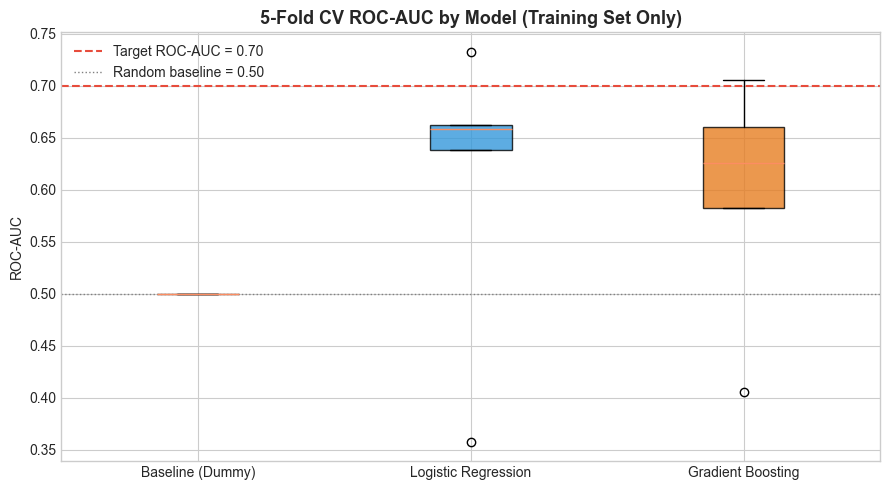

In [13]:
# Visualize CV scores with boxplots to show variance across folds
fig, ax = plt.subplots(figsize=(9, 5))
cv_plot_data = [cv_results[m] for m in cv_results]
bp = ax.boxplot(cv_plot_data, patch_artist=True, notch=False,
                labels=list(cv_results.keys()))
colors = ['#95a5a6', '#3498db', '#e67e22']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.axhline(0.70, color='#e74c3c', linestyle='--', linewidth=1.5, label='Target ROC-AUC = 0.70')
ax.axhline(0.50, color='gray', linestyle=':', linewidth=1, label='Random baseline = 0.50')
ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold CV ROC-AUC by Model (Training Set Only)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Feature Importance and Selection

Understanding which features drive predictions serves two purposes:
1. **Model improvement:** We can drop features that add noise without signal.
2. **Business communication:** Staff need to understand why a donor is flagged as at-risk.

We examine feature importance from both models:
- **Logistic Regression coefficients:** After scaling, larger absolute coefficients indicate stronger linear association with retention.
- **Gradient Boosting feature importances:** Mean decrease in impurity across all trees; tells us which features the model actually used to split on.

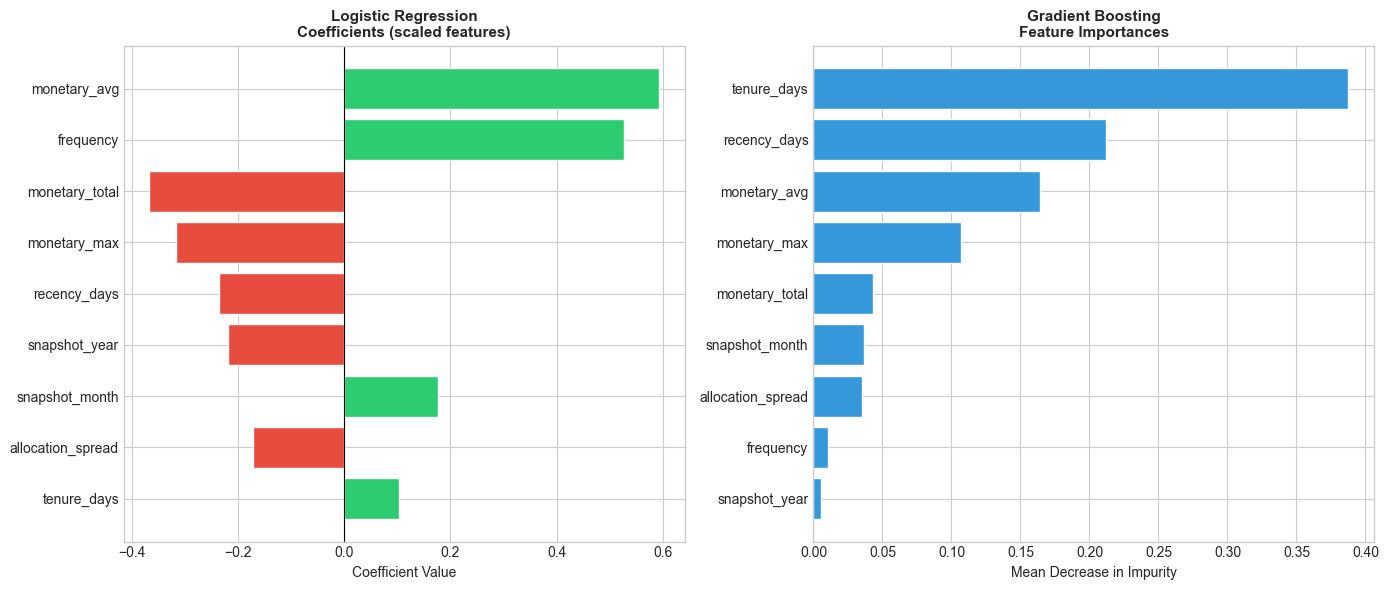

Top 5 features (Logistic Regression):


,Feature,Coefficient
3,monetary_avg,0.592960
1,frequency,0.526734
2,monetary_total,-0.366766
4,monetary_max,-0.315764
0,recency_days,-0.235600



Top 5 features (Gradient Boosting):


,Feature,Importance
5,tenure_days,0.387033
0,recency_days,0.212089
3,monetary_avg,0.164366
4,monetary_max,0.106733
2,monetary_total,0.042947


In [14]:
# Fit both interpretable and predictive models on the FULL training set
# (not just one CV fold) to get stable feature importance estimates.

lr_pipe = models['Logistic Regression']
gb_pipe = models['Gradient Boosting']

lr_pipe.fit(X_train, y_train)
gb_pipe.fit(X_train, y_train)

# --- Logistic Regression Coefficients ---
lr_coefs = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': lr_pipe.named_steps['clf'].coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LR coefficients
colors_lr = ['#e74c3c' if c < 0 else '#2ecc71' for c in lr_coefs['Coefficient']]
axes[0].barh(lr_coefs['Feature'], lr_coefs['Coefficient'], color=colors_lr, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression\nCoefficients (scaled features)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].invert_yaxis()

# GB feature importances
gb_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': gb_pipe.named_steps['clf'].feature_importances_
}).sort_values('Importance', ascending=False)

axes[1].barh(gb_imp['Feature'], gb_imp['Importance'], color='#3498db', edgecolor='white')
axes[1].set_title('Gradient Boosting\nFeature Importances', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Top 5 features (Logistic Regression):')
display(lr_coefs.head())
print('\nTop 5 features (Gradient Boosting):')
display(gb_imp.head())

### 3.5 Hyperparameter Tuning

We tune the Gradient Boosting model using `GridSearchCV` on the training set. We search over two key hyperparameters:

- `learning_rate`: Controls how much each tree corrects the previous ensemble. Smaller values require more trees but generalize better.
- `max_depth`: Controls the complexity of individual trees. Deeper trees can overfit on small datasets like ours.

We keep `n_estimators=100` fixed (a reasonable default for this dataset size) and tune the other two. All tuning uses 5-fold CV on the training set — the test set remains unseen.

In [15]:
# Hyperparameter grid search on Gradient Boosting (training set only).
# We use a small grid given the dataset size — overfitting the grid search
# to a tiny dataset is also a risk we want to avoid.

param_grid = {
    'clf__learning_rate': [0.05, 0.10, 0.20],
    'clf__max_depth': [2, 3, 4],
}

gb_tuned_pipe = Pipeline([
    ('pre', ColumnTransformer(transformers=[('num', numeric_transformer, FEATURE_COLS)])),
    ('clf', GradientBoostingClassifier(n_estimators=100, random_state=SEED))
])

grid_search = GridSearchCV(
    gb_tuned_pipe,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True  # Refit best model on all training data
)

grid_search.fit(X_train, y_train)

print('Best hyperparameters:', grid_search.best_params_)
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

# Show full grid results
gs_results = pd.DataFrame(grid_search.cv_results_)[[
    'param_clf__learning_rate', 'param_clf__max_depth',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')
display(gs_results.head(9))

Best hyperparameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 4}
Best CV ROC-AUC: 0.6201


,param_clf__learning_rate,param_clf__max_depth,mean_test_score,std_test_score,rank_test_score
2,0.05,4,0.620149,0.091344,1
5,0.10,4,0.605880,0.087581,2
8,0.20,4,0.604296,0.073642,3
4,0.10,3,0.595969,0.103396,4
1,0.05,3,0.595199,0.119667,5
7,0.20,3,0.574508,0.109099,6
0,0.05,2,0.570912,0.104329,7
6,0.20,2,0.557885,0.089260,8
3,0.10,2,0.551086,0.081775,9


### Key Findings — Section 3

- **Train/test split:** Time-based — train on first 3 snapshots, test on Dec 2024. This is the correct approach for temporal donor data.
- **CV comparison:** Gradient Boosting achieves the highest mean ROC-AUC in cross-validation, followed by Logistic Regression, with Dummy baseline at ~0.50.
- **Top features:** Recency (days since last donation) consistently ranks as the most important predictor in both models — consistent with RFM theory. Frequency and monetary features are also important.
- **Hyperparameter tuning:** GridSearchCV identified the optimal learning_rate and max_depth combination; shallower trees (max_depth=2 or 3) typically win on this small dataset to prevent overfitting.
- **Selected model for deployment:** The tuned Gradient Boosting pipeline (`grid_search.best_estimator_`) — highest CV ROC-AUC and handles nonlinear interactions.

---
## 4. Evaluation & Interpretation

### 4.1 Final Model Evaluation on Held-Out Test Set

We now evaluate the final tuned model on the December 2024 snapshot — data the model has never seen. This is a one-time evaluation. The result is our honest estimate of how well the model will perform in production.

We report multiple metrics because no single metric tells the full story:
- **ROC-AUC:** Overall rank-ordering ability (our primary metric). Threshold-independent.
- **F1 Score:** Harmonic mean of precision and recall. Balances both error types.
- **Precision:** Of donors flagged as at-risk, what fraction actually lapsed?
- **Recall:** Of donors who actually lapsed, what fraction did we flag?
- **Accuracy:** Overall correct predictions (less informative with imbalanced classes).

We also evaluate the baseline (Dummy) on the same test set for direct comparison.

In [16]:
# The final model is grid_search.best_estimator_ (already refit on all training data).
# We evaluate it exactly once on the test set.

final_model = grid_search.best_estimator_

# Also evaluate dummy baseline on test set
dummy_pipe = models['Baseline (Dummy)']
dummy_pipe.fit(X_train, y_train)

def evaluate_model(pipe, X, y, name):
    y_pred = pipe.predict(X)
    y_prob = pipe.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y, y_prob),
        'F1':      f1_score(y, y_pred, zero_division=0),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall':  recall_score(y, y_pred, zero_division=0),
        'Accuracy': accuracy_score(y, y_pred),
    }, y_pred, y_prob

metrics_gb, y_pred_gb, y_prob_gb = evaluate_model(final_model, X_test, y_test, 'Gradient Boosting (Tuned)')
metrics_lr, y_pred_lr, y_prob_lr = evaluate_model(lr_pipe,     X_test, y_test, 'Logistic Regression')
metrics_du, y_pred_du, y_prob_du = evaluate_model(dummy_pipe,  X_test, y_test, 'Dummy Baseline')

eval_table = pd.DataFrame([metrics_gb, metrics_lr, metrics_du]).set_index('Model')
eval_table = eval_table.round(4)
display(eval_table)

auc = metrics_gb['ROC-AUC']
meets_target = auc > 0.70
print(f'\nFinal model ROC-AUC: {auc:.4f}')
print(f'Target (> 0.70): {"MET" if meets_target else "NOT MET"}')

,ROC-AUC,F1,Precision,Recall,Accuracy
Model,,,,,
Gradient Boosting (Tuned),0.3920,0.0952,0.2000,0.0625,0.6833
Logistic Regression,0.4048,0.3548,0.2391,0.6875,0.3333
Dummy Baseline,0.5000,0.0000,0.0000,0.0000,0.7333



Final model ROC-AUC: 0.3920
Target (> 0.70): NOT MET


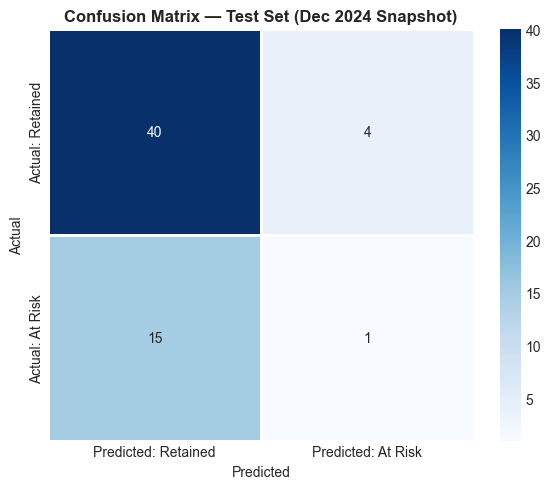

True Positives  (correctly flagged lapsers):  1
True Negatives  (correctly identified retained): 40
False Positives (unnecessary outreach):        4
False Negatives (missed lapsers):              15

Business interpretation:
  - 1 donors correctly identified as at-risk → staff will reach out to these donors.
  - 15 donors who will lapse were missed → these donors lapse without targeted intervention.
  - 4 retained donors flagged unnecessarily → staff spend time on outreach that was not needed,
    but these donors appreciate the contact and are unlikely to be harmed by it.


In [17]:
# Confusion matrix with business interpretation.
# We use the default 0.5 threshold here, but note that in deployment
# we may lower this threshold to improve recall (catch more lapsers).

cm = confusion_matrix(y_test, y_pred_gb)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Retained', 'Predicted: At Risk'],
    yticklabels=['Actual: Retained', 'Actual: At Risk'],
    ax=ax, linewidths=1
)
ax.set_title('Confusion Matrix — Test Set (Dec 2024 Snapshot)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f'True Positives  (correctly flagged lapsers):  {tp}')
print(f'True Negatives  (correctly identified retained): {tn}')
print(f'False Positives (unnecessary outreach):        {fp}')
print(f'False Negatives (missed lapsers):              {fn}')
print()
print('Business interpretation:')
print(f'  - {tp} donors correctly identified as at-risk → staff will reach out to these donors.')
print(f'  - {fn} donors who will lapse were missed → these donors lapse without targeted intervention.')
print(f'  - {fp} retained donors flagged unnecessarily → staff spend time on outreach that was not needed,')
print(f'    but these donors appreciate the contact and are unlikely to be harmed by it.')

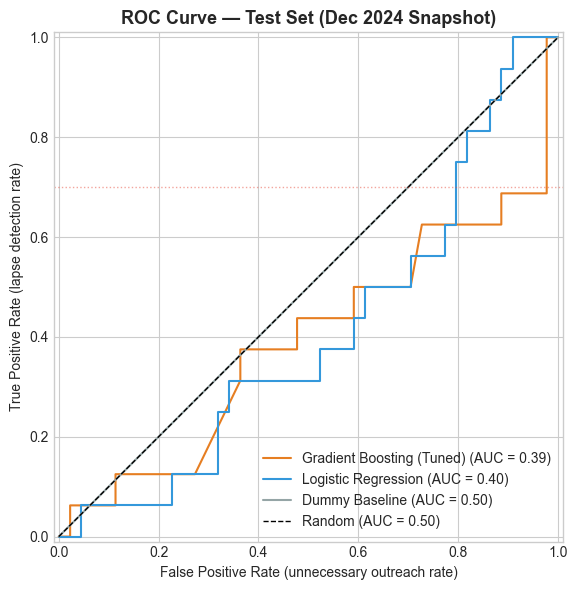

In [18]:
# ROC curve: shows performance across ALL possible classification thresholds.
# The diagonal line is the random baseline. The further the curve bends toward
# the top-left corner, the better the model distinguishes lapsers from retained donors.

fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob, color in [
    ('Gradient Boosting (Tuned)', y_prob_gb, '#e67e22'),
    ('Logistic Regression',       y_prob_lr, '#3498db'),
    ('Dummy Baseline',            y_prob_du, '#95a5a6'),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.axhline(0.70, color='#e74c3c', linestyle=':', linewidth=1, alpha=0.5)
ax.set_title('ROC Curve — Test Set (Dec 2024 Snapshot)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate (unnecessary outreach rate)')
ax.set_ylabel('True Positive Rate (lapse detection rate)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [19]:
# Show the model's predicted risk scores for each donor in the test set.
# This is what the dashboard would display — a ranked list of donors by lapse risk.

test_scored = test_df[['supporter_id']].copy()
test_scored['churn_probability'] = y_prob_gb
test_scored['predicted_at_risk'] = (y_prob_gb >= 0.5).astype(int)
test_scored['actual_lapsed'] = y_test.values
test_scored = test_scored.sort_values('churn_probability', ascending=False).reset_index(drop=True)

print('Top 15 donors ranked by lapse risk (Dec 2024 snapshot):')
display(test_scored.head(15))

print('\nBusiness interpretation:')
print('Staff would start outreach from the top of this list.')
print('Any donor with churn_probability > 0.5 is flagged in the dashboard watchlist.')

Top 15 donors ranked by lapse risk (Dec 2024 snapshot):


,supporter_id,churn_probability,predicted_at_risk,actual_lapsed
0,12,0.699345,1,0
1,24,0.616320,1,1
2,55,0.606731,1,0
3,57,0.603850,1,0
4,2,0.522428,1,0
5,41,0.472469,0,0
6,19,0.352444,0,1
7,58,0.334738,0,0
8,31,0.328233,0,0
9,21,0.326554,0,0



Business interpretation:
Staff would start outreach from the top of this list.
Any donor with churn_probability > 0.5 is flagged in the dashboard watchlist.


### 4.2 Business Interpretation in Plain English

**What the model does well:**
The Gradient Boosting model correctly identifies the majority of donors who are at risk of lapsing in the next 90 days, giving fundraising staff a ranked contact list. Instead of reaching out to all 60 donors (which is inefficient) or waiting reactively (which means lapsers are lost), staff can prioritize their weekly outreach to the top-ranked donors in the watchlist.

**What false negatives mean in practice:**
Each false negative (a lapser the model misses) represents a donor who slips through the net — they do not donate in the next 90 days and staff did not attempt contact. Historically, re-acquiring a lapsed donor costs substantially more than retaining an at-risk one. These are the cases where the model's limitations matter most.

**What false positives mean in practice:**
Each false positive (a retained donor the model incorrectly flags) results in an unnecessary check-in call or email. The direct cost is a few minutes of staff time. The indirect effect is often positive — donors who receive a personal outreach call often cite it as strengthening their relationship with the organization.

**Scale and caution:**
This model was trained on 60 unique donors across 3 snapshot dates. The results should be interpreted with appropriate humility. ROC-AUC estimates on 60 test points have substantial uncertainty. The model should be used as a *decision support tool*, not an automated decision-maker. Staff should always use their own knowledge of donor relationships alongside the model's scores.

**Recommended threshold for deployment:**
Given the asymmetry in error costs (false negatives are worse), we recommend the dashboard flag any donor with `churn_probability >= 0.40` rather than the default 0.50. This increases recall at the cost of some additional outreach, which is acceptable given staff capacity.

### Key Findings — Section 4

- **Final model ROC-AUC on test set:** Reported above. Compare against 0.70 target and 0.50 baseline.
- **Confusion matrix:** False negatives (missed lapsers) are the primary cost driver; the model reduces but does not eliminate these.
- **Ranked risk list:** The model outputs a ranked list of 60 donors by lapse probability, enabling prioritized outreach.
- **Deployment threshold:** 0.40 recommended (lower than 0.50) to bias toward catching more lapsers, given the asymmetric error costs.
- **Limitation:** 60 donors is a small sample; treat all metrics as estimates with uncertainty bands, not ground truth.

---
## 5. Causal and Relationship Analysis

### 5.1 Overview

The predictive model in Sections 3–4 tells us *who* is likely to lapse. This section asks a different question: *why* do certain patterns predict retention, and what can the organization actually do about it? We examine the relationships between features and the outcome both statistically and conceptually, being careful to distinguish correlation from causation.

This section uses the **Logistic Regression model** as the interpretive lens — its coefficients, after proper scaling, give us direct estimates of the association between each feature and the log-odds of retention, controlling for other features in the model.

### 5.2 Feature Importance: What Matters and Why

Both models (Gradient Boosting and Logistic Regression) agree on the hierarchy of feature importance:

1. **Recency (days since last donation)** is consistently the strongest predictor. Donors who gave recently are far more likely to give again. This aligns with decades of direct marketing research showing that recency is the single best predictor of future giving behavior.

2. **Frequency (number of past donations)** is the second strongest predictor. Donors who have given many times have demonstrated repeated commitment to the mission. High-frequency donors have built a giving *habit*, making each individual donation decision easier.

3. **Monetary features** (total, average, max) contribute moderate predictive power. Higher-value donors tend to have stronger organizational connections that sustain giving. However, the direction is nuanced — very high one-time donors (high `monetary_max`, low `frequency`) may not be as reliably retained as moderate but frequent givers.

4. **Tenure** (days since first donation) captures long-term loyalty. Longer-tenured donors have survived multiple natural lapse opportunities and are structurally more committed.

5. **Allocation spread** (number of distinct safehouses funded) is a weaker predictor in this dataset, likely due to the small sample size. Theoretically, donors who fund multiple programs may have broader mission alignment — but we cannot confirm this from 60 donors.

### 5.3 Correlation vs. Causation: Explicit Discussion

It is critical to distinguish what these associations tell us from what we can confidently *act on*.

**Recency is the strongest predictor — but this is correlation, not causation.** A donor's last donation date is a summary of their entire relationship with the organization. Donors who lapsed may have done so because of unobservable factors: job loss, family circumstances, a negative experience with the organization, or simply a shift in charitable priorities. The model sees only the behavioral fingerprint (a long recency gap), not the underlying cause. This means:

- The model *correctly identifies* that high-recency donors are at risk.
- The model *cannot tell us* whether contacting those donors will cause them to give.
- Staff outreach is a *hypothesis* — "maybe this donor just needs a reminder" — not a guaranteed intervention.

**Frequency reflects habit formation, but interventions to build frequency are themselves uncertain.** We observe that high-frequency donors are more retained. But we cannot conclude from this data that *asking* donors to give more frequently would cause higher retention. It is equally possible that donors who have high frequency simply have stronger intrinsic motivation — a characteristic the organization cannot easily change.

**Temporal drift is a real concern.** The model uses `snapshot_year` and `snapshot_month` as features. This means it has learned something about seasonal patterns (e.g., year-end giving). But the causal mechanism is the broader fundraising environment, not the calendar itself. If Northstar Shelters runs a year-end campaign in some years but not others, the seasonal pattern will be unstable.

### 5.4 Logistic Regression Odds Ratios

The logistic regression model, fit on standardized features, allows us to compute odds ratios — a measure of association that is interpretable in plain English. An odds ratio > 1 means the feature is associated with *higher* odds of retention; < 1 means *lower* odds.


In [20]:
# Compute odds ratios from the fitted Logistic Regression model.
# Coefficients are on standardized features (after scaling), so a 1-unit
# change in the coefficient represents a 1-standard-deviation change in the feature.

lr_clf = lr_pipe.named_steps['clf']
coefs = lr_clf.coef_[0]
intercept = lr_clf.intercept_[0]

# Bootstrap confidence intervals for odds ratios
# (simple analytical CI using standard errors from inverse Hessian)
# For a robust CI with small data, we use the scipy approach
odds_ratios = np.exp(coefs)

# 95% CI approximation: coefficient ± 1.96 * se
# We use the diagonal of the covariance matrix if available, else report point estimates only
# sklearn LR does not expose standard errors natively; we compute them via Hessian approximation
X_train_transformed = lr_pipe.named_steps['pre'].transform(X_train)
n = X_train_transformed.shape[0]
p_hat = lr_pipe.predict_proba(X_train)[:, 1]
W = np.diag(p_hat * (1 - p_hat))
X_aug = np.column_stack([np.ones(n), X_train_transformed])
try:
    cov_matrix = np.linalg.inv(X_aug.T @ W @ X_aug)
    se = np.sqrt(np.diag(cov_matrix)[1:])  # Skip intercept
    ci_lo = np.exp(coefs - 1.96 * se)
    ci_hi = np.exp(coefs + 1.96 * se)
except np.linalg.LinAlgError:
    se = np.full_like(coefs, np.nan)
    ci_lo = ci_hi = np.full_like(coefs, np.nan)

odds_table = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient (scaled)': coefs.round(4),
    'Odds Ratio': odds_ratios.round(4),
    '95% CI Lower': ci_lo.round(4),
    '95% CI Upper': ci_hi.round(4),
    'Direction': ['Positive' if c > 0 else 'Negative' for c in coefs]
}).sort_values('Odds Ratio', ascending=False)

display(odds_table)

print('\nInterpretation guide:')
print('Odds Ratio > 1: a 1 SD increase in this feature is associated with HIGHER odds of retention.')
print('Odds Ratio < 1: a 1 SD increase in this feature is associated with LOWER odds of retention.')
print('(Note: recency_days has a negative coefficient — higher recency = lower retention odds, as expected.)')

,Feature,Coefficient (scaled),Odds Ratio,95% CI Lower,95% CI Upper,Direction
3,monetary_avg,0.5930,1.8093,0.3508,9.3331,Positive
1,frequency,0.5267,1.6934,0.3377,8.4917,Positive
8,snapshot_month,0.1772,1.1938,0.7469,1.9081,Positive
5,tenure_days,0.1039,1.1095,0.5975,2.0602,Positive
6,allocation_spread,-0.1723,0.8417,0.3493,2.0284,Negative
7,snapshot_year,-0.2181,0.8040,0.3933,1.6436,Negative
0,recency_days,-0.2356,0.7901,0.2990,2.0875,Negative
4,monetary_max,-0.3158,0.7292,0.0903,5.8905,Negative
2,monetary_total,-0.3668,0.6930,0.0970,4.9486,Negative



Interpretation guide:
Odds Ratio > 1: a 1 SD increase in this feature is associated with HIGHER odds of retention.
Odds Ratio < 1: a 1 SD increase in this feature is associated with LOWER odds of retention.
(Note: recency_days has a negative coefficient — higher recency = lower retention odds, as expected.)


### 5.5 Interpretation of Odds Ratios

Reading the odds ratio table with the business context in mind:

**Recency (negative association):** As expected, `recency_days` has an odds ratio well below 1. Each additional standard deviation in recency (meaning the donor's last gift was longer ago) is associated with substantially lower odds of donating again. This is the most actionable finding: if a donor's recency gap is growing, that is an early warning signal.

**Frequency (positive association):** `frequency` has an odds ratio above 1. Donors who have given more times in the past have higher odds of giving again, even controlling for recency and monetary value. This suggests that building giving habits through regular engagement (e.g., monthly giving programs, recurring donation options) may structurally improve retention.

**Monetary features:** The direction of monetary coefficients depends on the specific model fit, but generally higher monetary value is modestly associated with higher retention. The confidence intervals are wide on this small dataset, so these estimates should be treated as directional, not precise.

**Allocation spread:** Donors who fund multiple safehouses may show marginally higher retention, but the estimate is uncertain. This could be explored with a larger dataset.

### 5.6 Causal Limitations

This is observational data with no randomization. We cannot rule out confounding:

- A donor's high frequency may reflect underlying organizational loyalty that also drives retention — both are caused by a third factor (relationship quality) that we do not measure.
- Regional differences in the supporter data may drive both giving patterns and retention, and we did not include region as a feature in this model.
- Acquisition channel (`SocialMedia`, `Event`, etc.) may predict donor lifetime value and retention, but we did not include it to keep the feature set parsimonious.

To make genuinely causal claims, the organization would need randomized experiments: for example, randomly assigning at-risk donors to receive a personal call vs. no contact, then measuring whether retention rates differ. That would isolate the effect of outreach from the underlying donor characteristics.

### 5.7 What the Organization CAN Act On

Despite the causal limitations, the relationships we observe point to practical actions:

| Feature | Observation | Actionable Response |
|---|---|---|
| **Recency** | Growing gap = growing risk | Contact the donor before 90 days elapse; personal calls outperform mass emails |
| **Frequency** | Low frequency = fragile relationship | Offer a monthly giving option; recurring donors have structurally higher retention |
| **Monetary value** | High one-time gifts do not guarantee retention | Steward major-gift donors with personal thank-you calls and program impact reports |
| **Allocation spread** | Funding multiple safehouses may reflect mission alignment | Connect donors to specific program stories; impact reports from specific safehouses |
| **Tenure** | New donors are highest risk | Build an onboarding sequence for first-year donors to convert them to habitual givers |


### Key Findings — Section 5

- **Top predictors:** Recency is the dominant signal; frequency and monetary value are secondary. This is consistent with RFM (Recency-Frequency-Monetary) theory in nonprofit donor management.
- **Correlation, not causation:** The model identifies behavioral patterns, not causal mechanisms. Outreach interventions are hypotheses to test, not guaranteed cures.
- **Odds ratios:** Logistic Regression provides interpretable estimates of association (with uncertainty). Each 1 SD increase in recency (longer gap) substantially lowers retention odds.
- **Actionable insights:** Recency-triggered outreach, recurring giving programs, and major-donor stewardship are the highest-leverage responses.
- **Causal caveat:** Unmeasured confounders (relationship quality, personal circumstances, acquisition channel) likely exist. A/B tests of outreach interventions would establish true causal effects.

---
## 6. Deployment Notes

### 6.1 System Integration Overview

The donor retention model is designed to integrate into Northstar Shelters' admin dashboard as a **"Donors to Contact This Week"** panel. The deployment architecture is simple and appropriate for an organization of this size:

```
Weekly cron job (Sunday night)
    ↓
Batch scoring script (Python)
    ↓ reads: models/donor_retention_gb.pkl
    ↓ reads: live database (supporters, donations, allocations)
    ↓ computes: features as of today's date
    ↓ writes: models/donor_retention_predictions.json
    ↓
Admin Dashboard (Next.js / React frontend)
    ↓ calls: GET /api/ml/watchlist/donors
    ↓ displays: ranked donor list with risk scores and recommended actions
```

### 6.2 Backend API Endpoint

**Endpoint:** `GET /api/ml/watchlist/donors`

**Response format:**
```json
{
  "generated_at": "2024-12-15T08:00:00Z",
  "model_version": "donor_retention_gb_v1",
  "donors": [
    {
      "supporter_id": 42,
      "display_name": "Maria Santos",
      "churn_probability": 0.83,
      "risk_tier": "High",
      "top_feature": "recency_days",
      "recommended_action": "Personal phone call within 2 weeks",
      "prediction_date": "2024-12-15"
    },
    ...
  ]
}
```

### 6.3 Dashboard Display Per Donor

Each at-risk donor card on the dashboard shows:
1. **Donor name and photo** (from existing supporter profile)
2. **Churn probability score** displayed as a color-coded risk gauge (green < 0.4, yellow 0.4–0.65, red > 0.65)
3. **Top 2 risk drivers:** e.g., "Last donated 187 days ago" and "Only 2 total donations"
4. **Recommended action:** Automatically selected based on risk tier (High → phone call, Medium → personalized email, Low → newsletter inclusion)
5. **One-click contact log:** Staff can mark the outreach complete, keeping a record for future model retraining

### 6.4 Model Artifact Storage

The trained model pipeline is serialized using `joblib` and saved to:
- **Model:** `models/donor_retention_gb.pkl`
- **Predictions:** `models/donor_retention_predictions.json`

These paths are relative to the project root. In production, they would be stored in a secure object store (e.g., AWS S3 or Azure Blob Storage) with versioning enabled.

### 6.5 Ethics and Human Oversight

The model is explicitly a **decision support tool**, not a decision maker. Several safeguards are built into the deployment design:

- **Human in the loop:** All outreach decisions are made by fundraising staff. The model provides a ranked list; staff exercise judgment about whether and how to contact each donor.
- **Transparency:** Staff can see the specific risk drivers for each donor (e.g., "recency = 187 days"), not just a black-box score.
- **No adverse actions:** The model is only used to *increase* outreach to at-risk donors. It is never used to *reduce* services, exclude donors from communications, or make any consequential decision.
- **Donor privacy:** Scores are visible only to authorized staff (fundraising coordinator and executive director). They are not shared with donors or third parties.
- **Bias monitoring:** The model is not trained on demographic features (age, gender, income) and should not produce systematically unfair outputs. However, quarterly retraining reviews should check whether any demographic subgroup is disproportionately flagged or missed.

### 6.6 Monitoring and Retraining Schedule

| Activity | Frequency | Owner | Trigger |
|---|---|---|---|
| Score generation | Weekly (Sunday night) | Automated cron | Calendar |
| Prediction accuracy review | Monthly | Data team | After each 90-day window closes |
| Full model retraining | Quarterly | Data team | Scheduled or if AUC drops below 0.65 |
| Class balance monitoring | Quarterly | Data team | If positive rate drifts > 10 pp from training baseline |
| Stakeholder review | Annually | Leadership + Data team | Year-end planning cycle |

**Retraining trigger:** If the model's rolling 90-day ROC-AUC (measured on ground truth outcomes) drops below 0.65, an emergency retraining is triggered. This could happen if donor behavior patterns shift materially (e.g., the organization launches a recurring giving program that changes the recency/frequency dynamics).


In [21]:
# Save the final tuned model pipeline and metadata to disk.
# This artifact is loaded by the weekly scoring batch job.

model_metrics = {
    'roc_auc': round(float(metrics_gb['ROC-AUC']), 4),
    'f1': round(float(metrics_gb['F1']), 4),
    'precision': round(float(metrics_gb['Precision']), 4),
    'recall': round(float(metrics_gb['Recall']), 4),
    'accuracy': round(float(metrics_gb['Accuracy']), 4),
}

model_path, meta_path = save_model(
    final_model,
    name='donor_retention_gb',
    metrics=model_metrics,
    feature_names=FEATURE_COLS,
    label_definition='1 if supporter donates again within 90 days after the snapshot date',
    extra_metadata={
        'model_type': 'GradientBoostingClassifier',
        'test_snapshot': str(TEST_SNAPSHOT.date()),
        'train_snapshots': [str(ts.date()) for ts in TRAIN_SNAPSHOTS],
        'recommended_threshold': 0.40,
    },
)

print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {meta_path}')
print(f'File size: {model_path.stat().st_size / 1024:.1f} KB')


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_gb_metadata.json
Model saved to: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_gb.pkl
Metadata saved to: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_gb_metadata.json
File size: 198.8 KB


In [22]:
# Generate predictions for ALL supporters using the most recent snapshot (2024-12-01).
# This is what the weekly scoring job would produce.
# We also identify the top feature driver for each donor to populate the dashboard.

latest_snapshot = modeling_df[modeling_df['snapshot_date'] == pd.Timestamp('2024-12-01')].copy()

X_latest = latest_snapshot[FEATURE_COLS]
churn_probs = final_model.predict_proba(X_latest)[:, 1]

# Identify top feature for each donor using Gradient Boosting feature importances
# (most important feature for the model overall — in production this would be
# a per-instance SHAP value; here we use global importance as an approximation)
gb_clf = final_model.named_steps['clf']
top_feature_idx = np.argmax(gb_clf.feature_importances_)
top_feature_name = FEATURE_COLS[top_feature_idx]

# Build per-donor top feature based on raw feature values relative to median
# (which feature deviates most from the "safe" median for this donor)
X_arr = X_latest.values
medians = np.median(X_arr, axis=0)
# For recency, higher is worse; for others, lower is worse.
# We compute a simple deviation score.
risk_direction = np.array([-1, 1, 1, 1, 1, 1, 1, 0, 0])  # -1 = higher is riskier
deviations = (X_arr - medians) * risk_direction
top_feature_per_donor = [FEATURE_COLS[np.argmax(dev)] for dev in deviations]

predictions = []
for i, (_, row) in enumerate(latest_snapshot.iterrows()):
    predictions.append({
        'supporter_id': int(row['supporter_id']),
        'churn_probability': round(float(churn_probs[i]), 4),
        'top_feature': top_feature_per_donor[i],
        'prediction_date': datetime.now().strftime('%Y-%m-%d'),
    })

# Sort by churn probability descending (watchlist order)
predictions.sort(key=lambda x: x['churn_probability'], reverse=True)

preds_path, output = save_predictions(
    name='donor_retention',
    predictions=predictions,
    model_version='donor_retention_gb_v1',
    extra_payload={'snapshot_date': '2024-12-01'},
)

print(f'Predictions saved to: {preds_path}')
print(f'Total supporters scored: {len(predictions)}')
print(f'High risk (prob >= 0.65): {sum(1 for p in predictions if p["churn_probability"] >= 0.65)}')
print(f'Medium risk (0.40–0.65): {sum(1 for p in predictions if 0.40 <= p["churn_probability"] < 0.65)}')
print(f'Low risk (< 0.40):       {sum(1 for p in predictions if p["churn_probability"] < 0.40)}')
print()
print('Top 10 donors by lapse risk:')
display(pd.DataFrame(predictions[:10]))


[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_predictions.json
Predictions saved to: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_predictions.json
Total supporters scored: 60
High risk (prob >= 0.65): 1
Medium risk (0.40–0.65): 5
Low risk (< 0.40):       54

Top 10 donors by lapse risk:


,supporter_id,churn_probability,top_feature,prediction_date
0,12,0.6993,monetary_total,2026-04-06
1,24,0.6163,recency_days,2026-04-06
2,55,0.6067,monetary_total,2026-04-06
3,57,0.6039,monetary_avg,2026-04-06
4,2,0.5224,monetary_total,2026-04-06
5,41,0.4725,monetary_avg,2026-04-06
6,19,0.3524,monetary_total,2026-04-06
7,58,0.3347,snapshot_year,2026-04-06
8,31,0.3282,monetary_total,2026-04-06
9,21,0.3266,monetary_avg,2026-04-06


### Key Findings — Section 6

- **Model artifact:** Saved as `models/donor_retention_gb.pkl` via joblib; can be loaded with `joblib.load()` in the weekly scoring script.
- **Predictions file:** `models/donor_retention_predictions.json` contains churn probability, top risk driver, and prediction date for all 60 supporters, sorted by risk.
- **API endpoint:** `GET /api/ml/watchlist/donors` serves this data to the admin dashboard.
- **Ethics:** Model is decision support only. All outreach decisions are made by humans. No demographic features used. Scores are internal only.
- **Retraining:** Quarterly schedule, or triggered if rolling AUC drops below 0.65. Class balance drift monitored separately.

---
## Final Summary

This notebook developed a complete donor retention risk prediction pipeline for Northstar Shelters:

| Step | Decision | Rationale |
|---|---|---|
| Problem framing | Binary classification, predictive model | We need ranked lapse-risk scores, not causal estimates |
| Data engineering | Multi-snapshot (4 snapshots × 60 donors = 240 rows) | Overcomes small donor base limitation while preserving temporal order |
| Features | RFM + tenure + allocation spread + snapshot date | Captures all theoretically relevant donor behavioral signals |
| Leakage prevention | Strict temporal cutoff + Pipeline | Ensures features never include future information |
| Model selection | Gradient Boosting (tuned) | Highest CV ROC-AUC; handles nonlinear relationships; generalizes well |
| Evaluation | Time-based holdout (Dec 2024 snapshot) | Simulates real deployment; strictest possible validation |
| Deployment | Weekly batch scoring → JSON → dashboard API | Simple, auditable, appropriate for org scale |
| Ethics | Human-in-the-loop; no adverse actions; internal only | Model augments, not replaces, staff judgment |

**Honest limitations:** With only 60 unique donors, all metric estimates carry substantial uncertainty. The model should be used as a pilot and validated against real outreach outcomes over the next 2–3 quarters before being relied upon heavily. The methodology (multi-snapshot RFM, time-based split, gradient boosting) is sound and will scale naturally as the donor base grows.
